# 초기 100사이클 기반 배터리 총수명 예측

이 노트북은 `main.py`와 같은 공통 단계 코드를 순서대로 호출합니다.

```text
config.py
    ↓
ExperimentRunner(CONFIG)
    ↓
단계별 셀: 데이터 준비 → 피처 계산 → EDA → 단계별 CV → 최종 학습 → 평가
```

- 실행 설정은 노트북에 복사하지 않고 `config.py`에서 읽습니다.
- 각 단계는 해당 절의 코드 셀을 실행할 때 수행됩니다.
- 같은 단계 셀을 다시 실행하면 완료된 상태를 재사용하여 중복 학습하지 않습니다.
- Batch3는 읽지 않습니다.
- 그래프는 `assets/`에 PNG로 저장합니다. 결과 CSV·모델 파일은 저장하지 않습니다.
- 실행 결과는 Batch2를 이미 확인한 후속 탐색 실험입니다.

## 1. 공통 코드와 설정 불러오기

노트북 위치를 기준으로 프로젝트 루트를 찾습니다. 개인 컴퓨터의 절대경로는 사용하지 않습니다.

In [1]:
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "config.py").is_file():
    candidates = [
        parent / "DS-MINI"
        for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]
        if (parent / "DS-MINI" / "config.py").is_file()
    ]
    if not candidates:
        raise FileNotFoundError("DS-MINI/config.py 위치를 확인하세요.")
    PROJECT_ROOT = candidates[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import CONFIG
from src.experiment import ExperimentRunner
from src.reporting import (
    candidate_preview,
    eda_findings,
    feature_catalog_preview,
    feature_range_preview,
    gap_summary,
    group_error_preview,
    performance_summary,
    plot_eda,
    plot_results,
    protocol_comparison_preview,
    quality_summary,
    redundancy_preview,
    rest_summary_preview,
    stage_summary,
    train_correlation_preview,
)

CONFIG.validate()
print("프로젝트 루트:", PROJECT_ROOT)
print("데이터 기본 위치:", CONFIG.data_dir)

프로젝트 루트: /Users/a123/workspace/W14-2.DataAnalysis/DS-MINI
데이터 기본 위치: /Users/a123/workspace/W14-2.DataAnalysis/DS-MINI/data/raw


## 2. 원본 읽기와 셀 분할

실험 상태 객체를 만들고 Batch1·2 원본을 읽은 뒤 Train 36셀, Valid 10셀, Batch2 39셀을 확정합니다.

설정을 변경하려면 이 셀을 수정하지 않고 `config.py`를 수정한 뒤 커널을 다시 시작합니다.

In [2]:
runner = ExperimentRunner(CONFIG, progress=True)
runner.load_data_and_split()
result = runner.result()
print("원본 읽기와 셀 분할 완료")

[1/10] Batch1·2 원본 읽기와 품질 처리
원본 읽기와 셀 분할 완료


## 3. 환경·설정·분할 확인

실제 적용된 버전과 설정, 셀 단위 분할을 확인합니다.

In [3]:
display(result.environment)
display(result.settings)
display(
    result.split_assignments.groupby(["batch", "role"], sort=False)
    .size()
    .rename("셀 수")
    .reset_index()
)
display(result.cv_folds.sort_values(["validation_fold", "cell_id"]).head(10))

,항목,버전
0,Python,3.14.6
1,numpy,2.5.3
2,pandas,3.0.6
3,h5py,3.16.0
4,scikit-learn,1.9.1
5,matplotlib,3.11.2
6,joblib,1.6.0


,설정,값
0,데이터 위치,/Users/a123/workspace/W14-2.DataAnalysis/DS-MI...
1,난수,42
2,Batch1 검증 셀 수,10
3,Train CV,5-fold
4,타깃 후보,"original, log10"
5,모델 후보,"elastic_net, ridge, random_forest"
6,결측 대체,CV 학습 fold 중앙값
7,표준화,CV 학습 fold 평균·표준편차
8,주 선택 지표,CV 평균 MAPE
9,1차 분기별 생존 수,3


,batch,role,셀 수
0,Batch 1,train,36
1,Batch 1,valid,10
2,Batch 2,test,39
3,Batch 2,unlabeled,8


,cell_id,validation_fold
0,2017-05-12_batchdata_updated_struct_errorcorre...,1
1,2017-05-12_batchdata_updated_struct_errorcorre...,1
2,2017-05-12_batchdata_updated_struct_errorcorre...,1
3,2017-05-12_batchdata_updated_struct_errorcorre...,1
4,2017-05-12_batchdata_updated_struct_errorcorre...,1
5,2017-05-12_batchdata_updated_struct_errorcorre...,1
6,2017-05-12_batchdata_updated_struct_errorcorre...,1
7,2017-05-12_batchdata_updated_struct_errorcorre...,1
8,2017-05-12_batchdata_updated_struct_errorcorre...,2
9,2017-05-12_batchdata_updated_struct_errorcorre...,2


## 4. 데이터 품질과 초기 피처

Batch1 첫 사이클 빈 측정, 내부저항 0, 확인된 손상 온도와 충전 조건 해석 상태를 확인합니다. 셀을 삭제하거나 수명 라벨을 바꾸지 않습니다.

In [4]:
runner.build_features()
result = runner.result()
display(quality_summary(result))
display(
    result.data_quality.groupby(["batch", "policy_status"], sort=False)
    .size()
    .rename("셀 수")
    .reset_index()
)
display(
    result.feature_quality.groupby("delta_q_status", sort=False)
    .size()
    .rename("셀 수")
    .reset_index()
)
display(feature_catalog_preview(result, n=10))

[2/10] 초기 100사이클 피처 계산


,항목,값
0,전체 셀,93
1,수명 라벨 보유,85
2,Batch1 첫 사이클 빈 측정 처리 셀,46
3,IR 0 제외 건수,757
4,손상 온도 처리 행,100
5,충전 조건 해석 실패 셀,4
6,바코드 해석 불가 셀,93
7,cycle5 전류·시간 확보 셀,93
8,ΔQ 계산 이상 셀,0


,batch,policy_status,셀 수
0,Batch 1,정상,46
1,Batch 2,정상,43
2,Batch 2,충전 조건 해석 실패,4


,delta_q_status,셀 수
0,정상,93


,feature_set,family,variant,parent,n_features,features
0,A,design,existing,,1,delta_q_log_variance
14,A_ir_change,changed,changed,,2,"delta_q_log_variance, ir_change"
9,legacy_capacity_ir,legacy,existing,,3,"mean_qd, qd_slope, mean_ir"
13,A_temperature_change,changed,changed,,2,"delta_q_log_variance, temperature_change"
12,normalized_delta_q,changed,changed,,2,"normalized_delta_q_log_variance, normalized_de..."
1,B,design,existing,,2,"delta_q_log_variance, delta_q_min"
11,B_relative_capacity,changed,changed,,3,"delta_q_log_variance, delta_q_min, relative_ca..."
10,B_without_mean_qd,changed,changed,,3,"delta_q_log_variance, delta_q_min, qd_slope"
4,C_resistance,design,existing,,3,"delta_q_log_variance, delta_q_min, mean_ir"
2,C_time,design,existing,,3,"delta_q_log_variance, delta_q_min, mean_charge..."


## 5. EDA와 후보 구성 근거

현재 품질 처리 규칙을 적용한 값으로 다시 계산합니다. 피처-수명 상관과 피처 중복은 Train 36셀만 사용하며, Batch2는 분포 설명에만 사용합니다. 전체 Qd와 cycle5 무전류 구간은 설명용이며 모델 입력에는 포함하지 않습니다.

[3/10] Train 근거 EDA와 설명용 배치 진단


,주제,관측한 내용,예측 문제,대응 후보,CV·평가 확인
0,단수명 분포 이동,"Train 단수명 0셀, Batch2는 28셀(71.8%).",학습 범위보다 짧은 셀의 수명을 길게 예측할 위험이 있다.,원·로그 타깃과 제한된 Random Forest를 비교하고 단수명 셀을 제거하지 않았다.,"평가 전이며, 최종 모델 고정 후 단수명 과대 예측을 확인한다."
1,초기 용량 변화,Train에서 Qd 기울기가 0 이상인 셀은 13/36셀이다.,초기 평균 용량이나 단일 기울기만으로 열화를 구분하기 어렵다.,"ΔQ A·B, 평균 Qd 제외, 상대 용량 변화, 정규화 ΔQ 후보를 비교했다.",평가 전이며 기존·변경 피처 대표를 Train CV로 비교한다.
2,충전 프로토콜 표기,원문 기준 프로토콜 35개 조합을 확인했고 접미사를 보존했다.,같은 C1·C2·SOC라도 newstructure 등 실험 조건 차이를 숫자 세 개...,C-policy 후보를 비교하되 원문·접미사는 모델 입력이 아닌 사후 그룹 분석에 ...,평가 전이며 C-policy와 B 후보를 같은 Train CV로 비교한다.
3,cycle5 무전류 구간,"긴 무전류 구간 30셀, 평균수명 453.0; 짧은 무전류 구간 9셀, 평균수명 9...",배치·실험 조건 이동이 단수명 과대 예측과 함께 나타날 수 있다.,무전류 그룹은 설명·오류 분석에만 사용하고 모델 선택에는 넣지 않았다.,모델 고정 후 무전류 그룹별 오류를 사후 비교한다.
4,Train 상관·중복,Train 전용 상위 연관은 normalized_delta_q_log_varianc...,소표본에서 상관 탐색과 중복 피처가 계수와 선택을 불안정하게 만들 수 있다.,피처군을 나누고 Ridge·ElasticNet 규제와 제한된 후보 선별을 사용했다.,규제 선형모델과 Random Forest를 같은 Train CV로 비교한다.
5,ΔQ 곡선,전압별 Q100-Q10을 93셀에서 확인했다.,총용량 평균에서 보이지 않는 전압별 변화를 요약해야 한다.,ΔQ 로그 분산·최솟값 A/B와 정규화 표현을 비교한다.,평가 전이며 기존·변경 피처 대표를 Train CV로 비교한다.
6,원본·로그 변환,"Train 수명 왜도 0.41, log10 수명 왜도 -0.01.",분포 압축 자체가 예측 성능을 보장하지 않는다.,원 수명·log10 수명을 같은 CV에서 비교한다.,규제 선형모델과 Random Forest를 같은 Train CV로 비교한다.
7,배치 피처·프로토콜 차이,Train P5~P95 범위와 배치별 주요 피처 분포·미관측 프로토콜 수를 확인했다.,다른 배치에서 입력 범위와 조건이 바뀔 수 있다.,Batch2 분포를 유지하고 피처를 자동 삭제·추가하지 않는다.,"평가 전이며, 최종 모델 고정 후 단수명 과대 예측을 확인한다."


,dataset,n,short_life_count,short_life_pct,long_life_count,long_life_pct,minimum,median,mean,maximum
0,Batch1,46,0,0.000000,10,21.739130,534.0,858.5,844.717391,1227.0
1,Train,36,0,0.000000,7,19.444444,534.0,849.5,830.666667,1190.0
2,Valid,10,0,0.000000,3,30.000000,616.0,874.5,895.300000,1227.0
3,Batch2,39,28,71.794872,3,7.692308,392.0,472.0,565.743590,1186.0


,dataset,n,valid_qd_slope,nondecreasing_qd_slope_count,nondecreasing_qd_slope_pct,valid_relative_change,nonnegative_relative_change_count,nonnegative_relative_change_pct,median_qd_slope,median_relative_change
0,Train,36,36,13,36.111111,36,19,52.777778,-0.000007,0.000048


,feature,n,pearson,spearman,absolute_spearman
10,normalized_delta_q_log_variance,36,-0.875900,-0.847287,0.847287
2,delta_q_log_variance,36,-0.871684,-0.838793,0.838793
11,normalized_delta_q_min,36,0.874932,0.838664,0.838664
3,delta_q_min,36,0.869742,0.813695,0.813695
5,mean_charge_time,36,0.585688,0.586009,0.586009
13,relative_capacity_change,36,0.565628,0.564515,0.564515
12,qd_slope,36,0.142601,0.432203,0.432203
15,temperature_change,36,-0.350163,-0.417273,0.417273
0,c_rate_stage1,36,-0.556393,-0.410747,0.410747
6,mean_ir,36,0.374568,0.391788,0.391788


...

,batch,charging_policy,protocol_variant,n,mean_life,median_life,minimum,maximum
2,Batch 1,4.8C(80%)-4.8C,기존 표기,2,753.000000,753.0,636.0,870.0
27,Batch 2,4.8C(80%)-4.8C,기존 표기,5,483.600000,492.0,437.0,514.0
28,Batch 2,4.8C(80%)-4.8C-newstructure,newstructure,3,871.666667,809.0,777.0,1029.0


,batch,rest_group,all_cells,labelled_cells,minimum_rest_minutes,maximum_rest_minutes,mean_life,short_life_count
2,Batch 2,긴 무전류 구간,34,30,4.916712,4.930315,453.000000,28
3,Batch 2,짧은 무전류 구간,13,9,0.163193,0.416667,941.555556,0


,batch,feature,n,spearman,scope
0,Batch 1,c_rate_stage1,46,-0.482714,설명용·후보 선택에 사용하지 않음
1,Batch 1,c_rate_stage2,46,0.047414,설명용·후보 선택에 사용하지 않음
2,Batch 1,switch_soc_pct,46,0.185159,설명용·후보 선택에 사용하지 않음
3,Batch 2,c_rate_stage1,39,0.055093,설명용·후보 선택에 사용하지 않음
4,Batch 2,c_rate_stage2,39,-0.118840,설명용·후보 선택에 사용하지 않음
5,Batch 2,switch_soc_pct,39,0.287813,설명용·후보 선택에 사용하지 않음


,batch,feature,n,median,train_p05,train_p95,outside_train_p05_p95_pct
0,Batch 1,c_rate_stage1,46,6.000000,3.600000,8.000000,0.000000
1,Batch 2,c_rate_stage1,43,5.200000,3.600000,8.000000,0.000000
2,Batch 1,c_rate_stage2,46,3.600000,3.000000,4.950000,4.347826
3,Batch 2,c_rate_stage2,43,4.500000,3.000000,4.950000,20.930233
4,Batch 1,delta_q_log_variance,46,-3.851160,-4.806240,-3.410779,8.695652
5,Batch 2,delta_q_log_variance,47,-3.494881,-4.806240,-3.410779,31.914894
6,Batch 1,delta_q_min,46,-0.036350,-0.060448,-0.015663,10.869565
7,Batch 2,delta_q_min,47,-0.053254,-0.060448,-0.015663,36.170213
8,Batch 1,ir_change,46,0.000092,-0.000204,0.000199,10.869565
9,Batch 2,ir_change,40,-0.000009,-0.000204,0.000199,50.000000


,batch,all_cells,unseen_protocol_cells
0,Batch 1,46,2
1,Batch 2,47,40


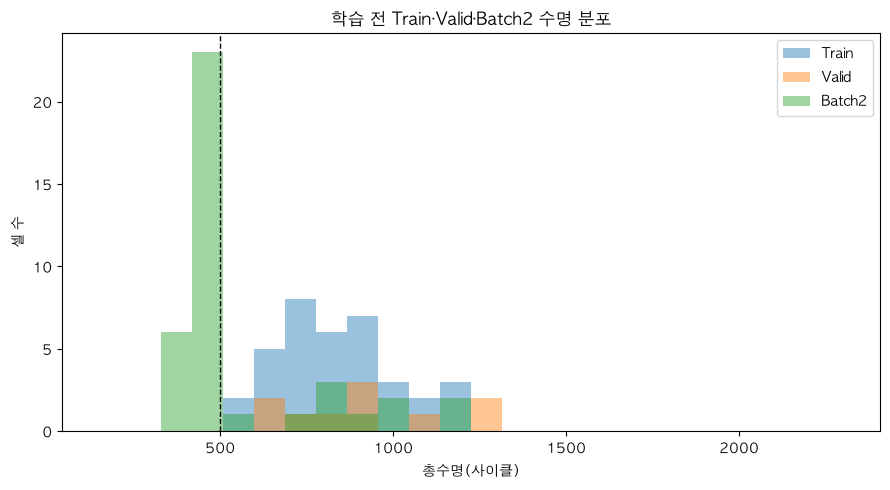

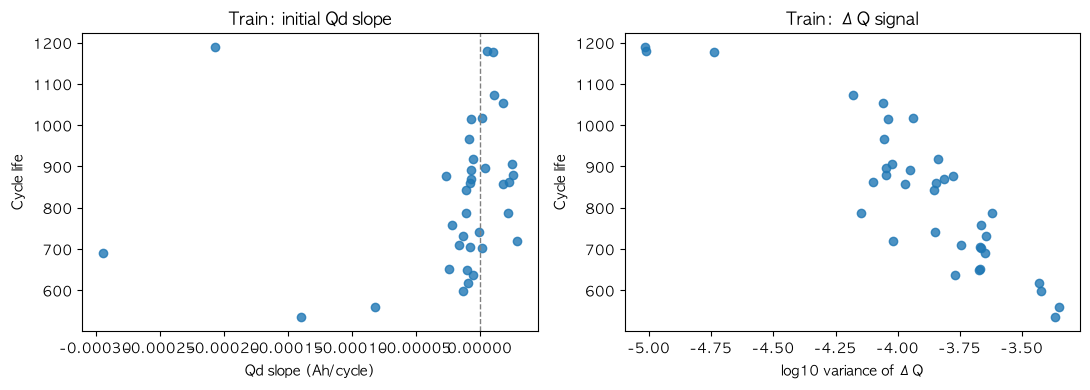

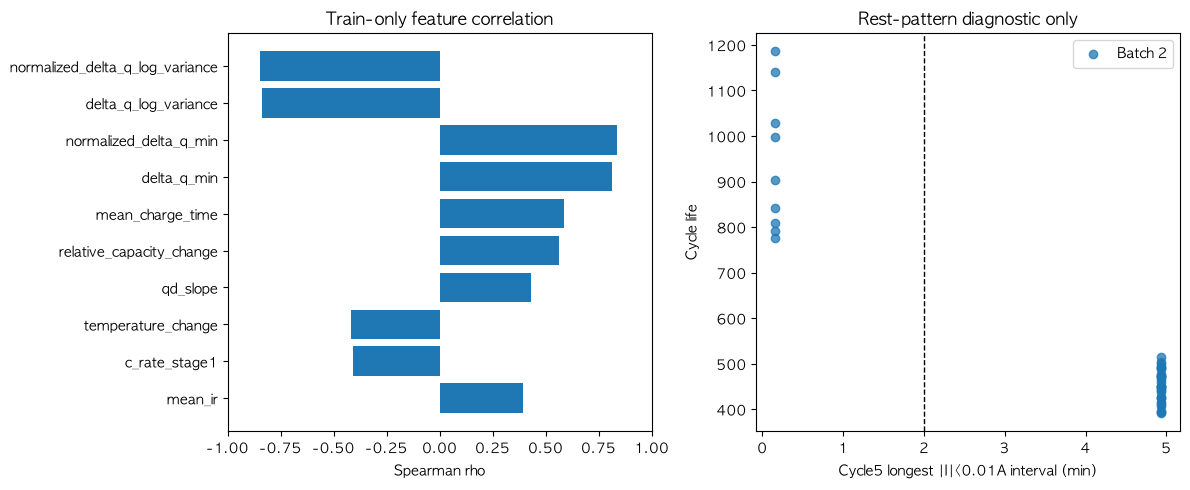

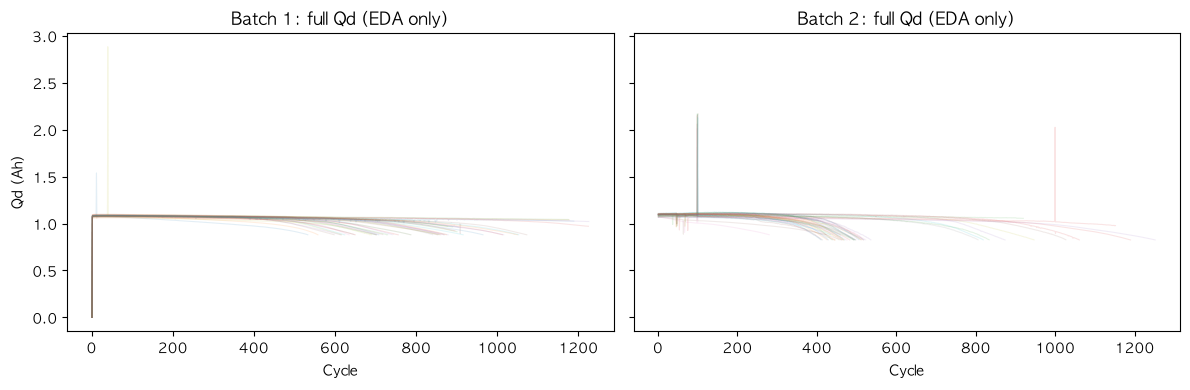

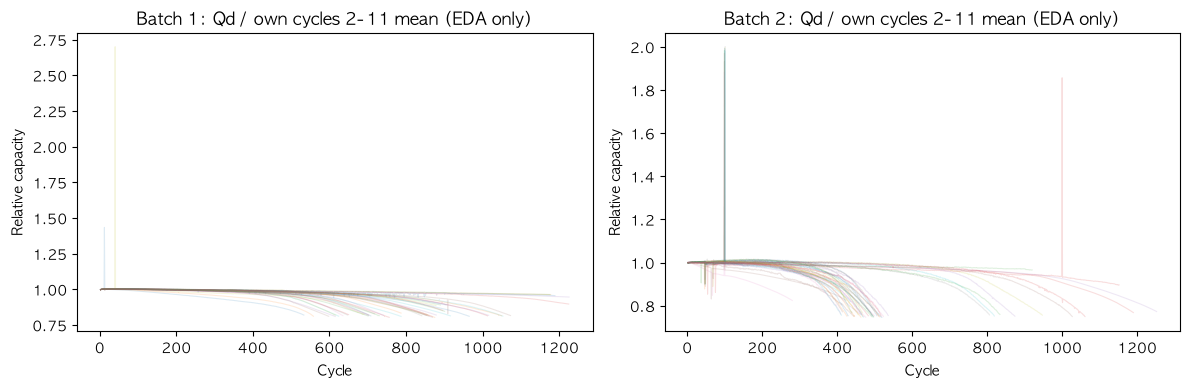

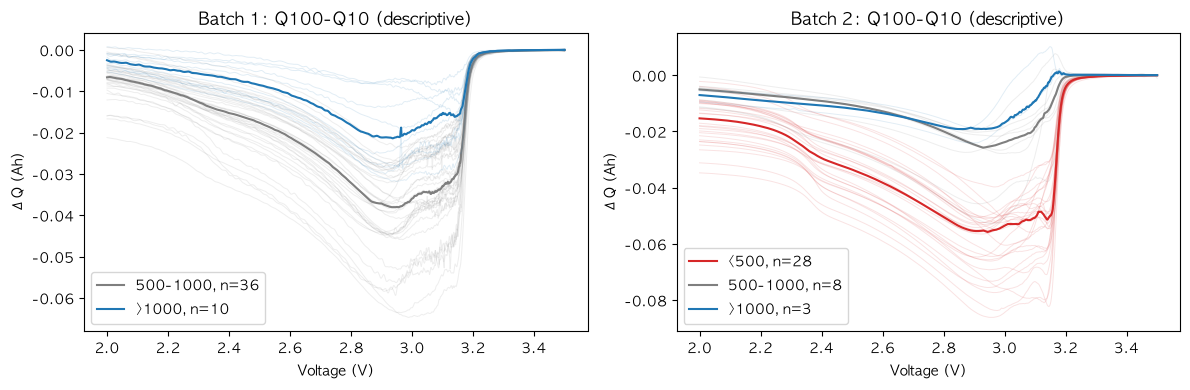

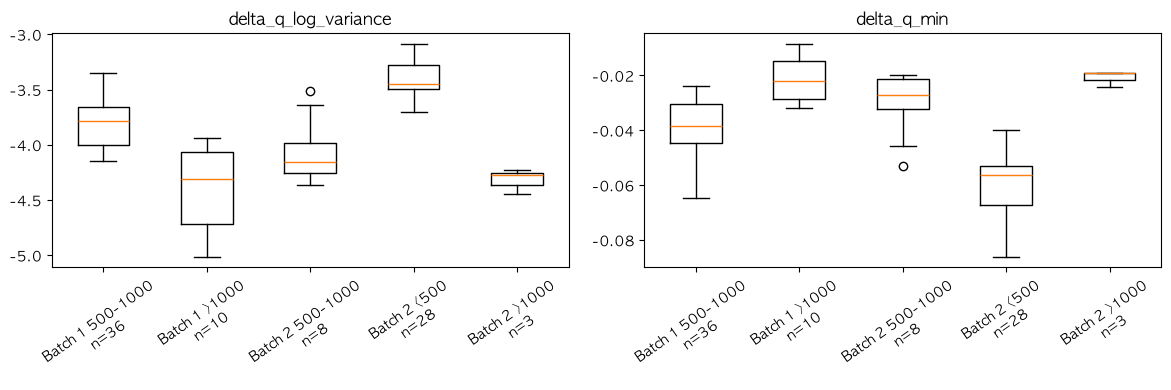

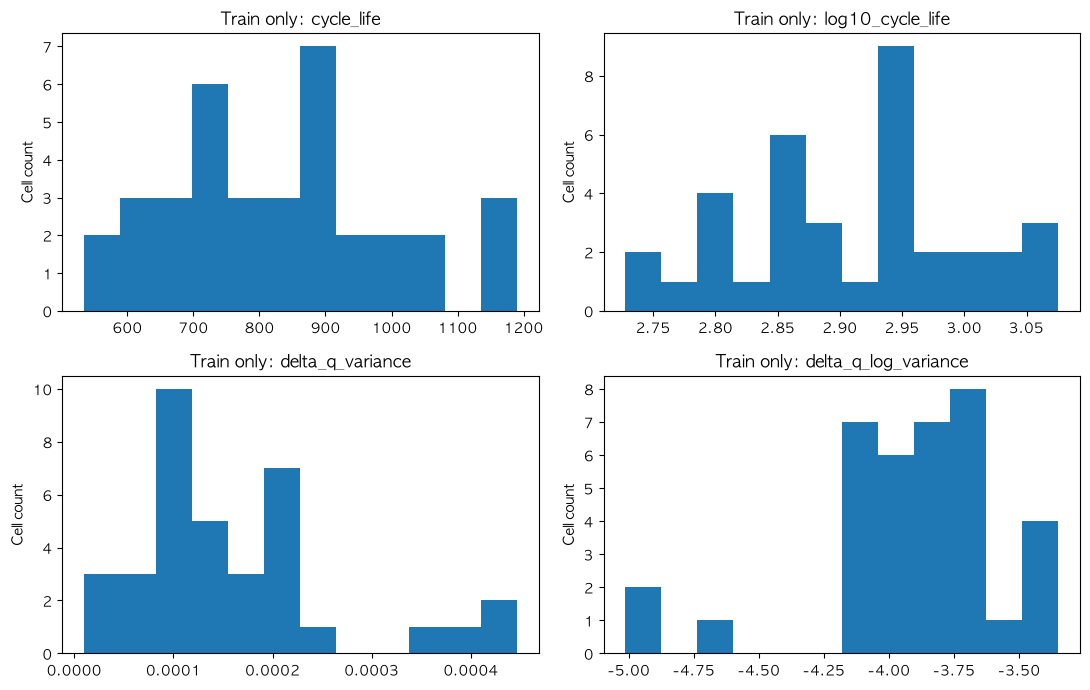

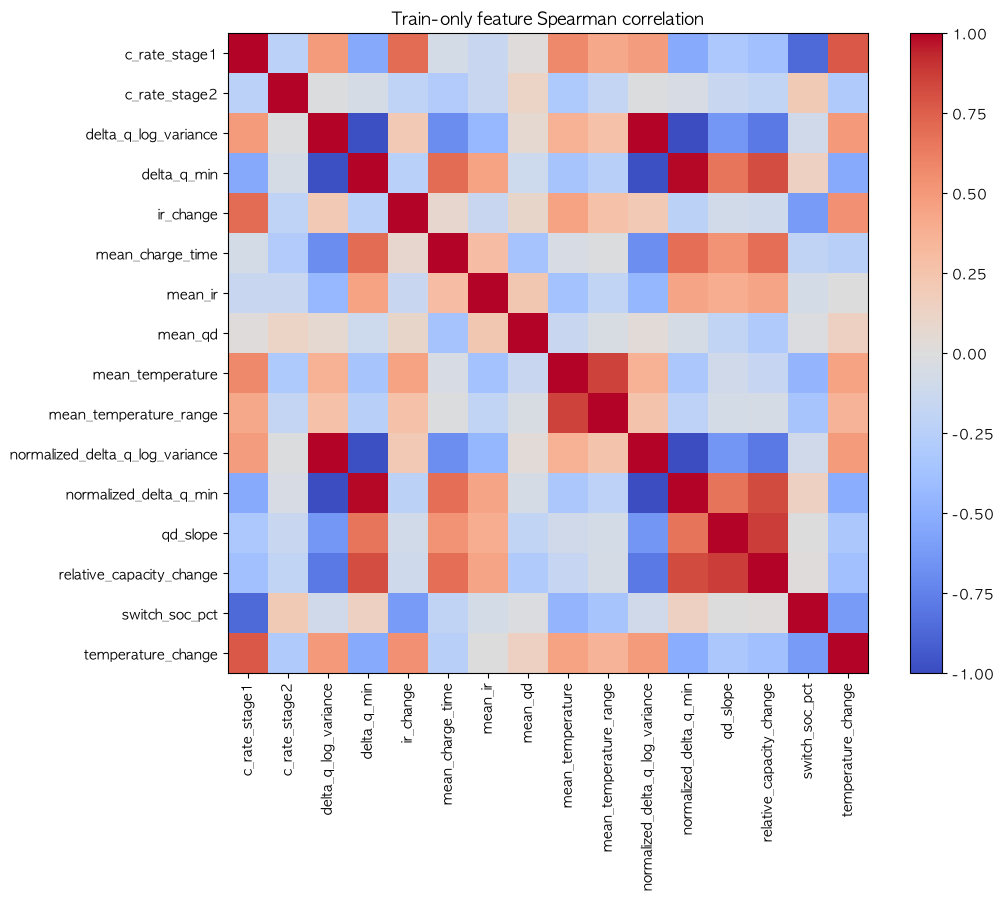

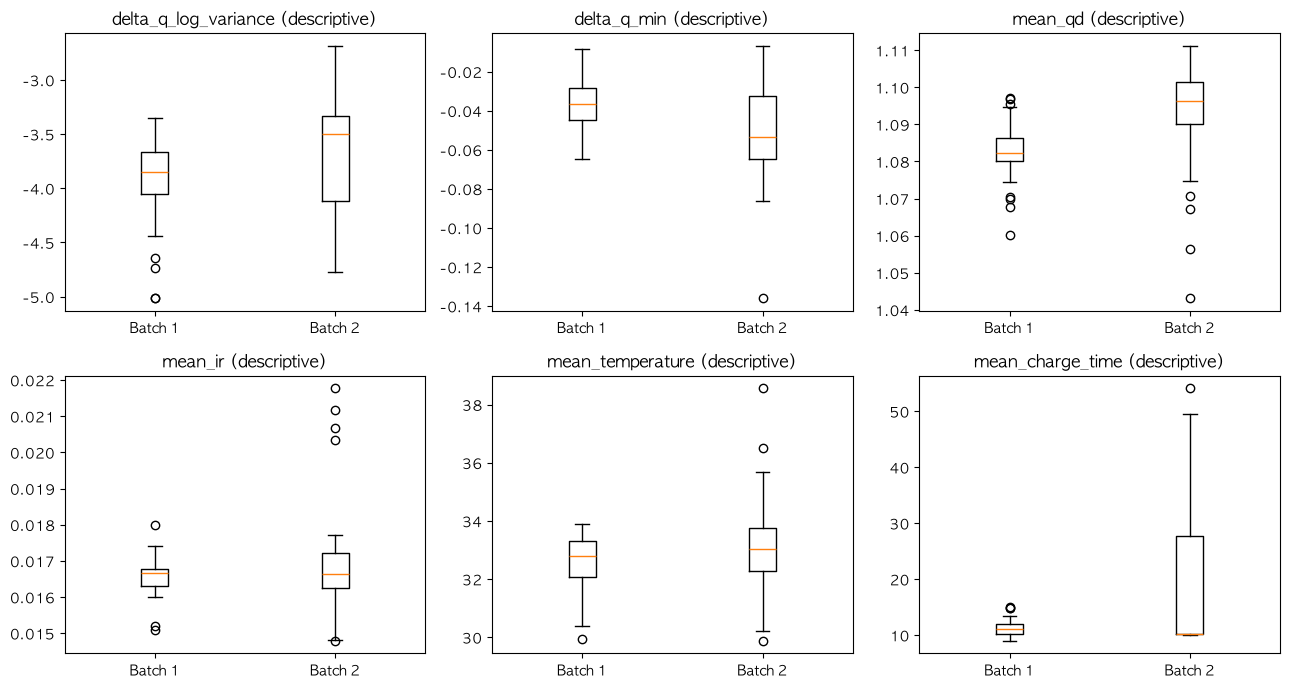

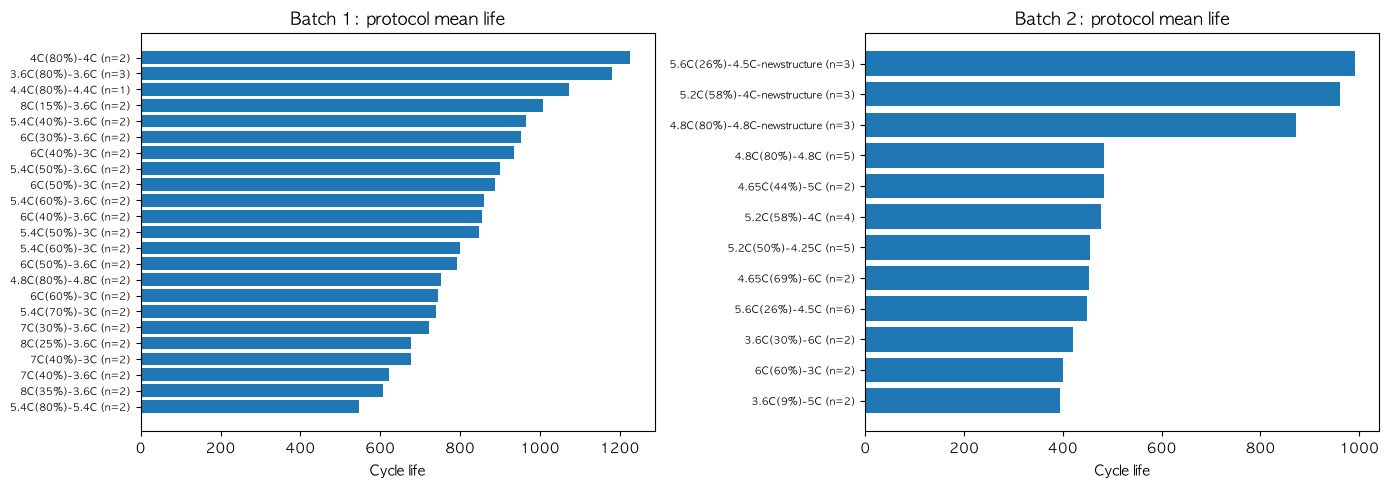

In [5]:
runner.run_eda()
result = runner.result()
display(eda_findings(result))
display(result.eda_tables["life_distribution"])
display(result.eda_tables["capacity_behavior"])
display(train_correlation_preview(result, n=10))
display(redundancy_preview(result, n=10))
display(protocol_comparison_preview(result, n=10))
display(rest_summary_preview(result))
for name in ["policy_correlations", "batch_feature_coverage", "protocol_coverage"]:
    display(result.eda_tables[name])
eda_figures = plot_eda(result) if CONFIG.show_eda_plots else []
for figure in eda_figures:
    display(figure)
    plt.close(figure)

## 6. 넓은 1차 교차검증

전체 초기 피처군 × 모델 × 타깃을 기본 설정으로 평가합니다. 계산은 전체 후보로 수행하고, 표에는 성능과 구성 다양성을 반영한 대표 후보를 최대 10개만 표시합니다.

In [6]:
runner.run_stage1()
result = runner.result()
display(stage_summary(result))
display(candidate_preview(result, "stage1", n=10))

[4/10] 전체 피처군 × 모델 × 타깃 1차 CV
  1차 CV: 1/90 - A / elastic_net / original
  1차 CV: 25/90 - C_resistance / elastic_net / original
  1차 CV: 50/90 - legacy_capacity_temperature / elastic_net / log10
  1차 CV: 75/90 - normalized_delta_q / ridge / original
  1차 CV: 90/90 - A_ir_change / random_forest / log10


,단계,평가 후보,정상 완료,경고·실패,생존 후보
0,stage1,90,90,0,54


,feature_set,family,variant,model,target_transform,params,branch_rank,cv_mape_mean,cv_mape_std,selected,selection_reason
21,C_capacity,design,existing,ridge,log10,"{""alpha"":1.0}",1,6.861112,0.618264,True,분기별 CV 상위 3개
18,C_capacity,design,existing,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",1,7.405651,0.355559,True,분기별 CV 상위 3개
72,normalized_delta_q,changed,changed,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",1,8.213483,2.590391,True,분기별 CV 상위 3개
45,legacy_capacity_policy,legacy,existing,ridge,log10,"{""alpha"":1.0}",1,10.400573,2.312244,True,분기별 CV 상위 3개
23,C_capacity,design,existing,random_forest,log10,"{""max_depth"":3,""min_samples_leaf"":3}",1,10.508983,3.006157,True,분기별 CV 상위 3개
20,C_capacity,design,existing,ridge,original,"{""alpha"":1.0}",1,7.449181,0.369329,True,분기별 CV 상위 3개
74,normalized_delta_q,changed,changed,ridge,original,"{""alpha"":1.0}",1,8.224877,2.661988,True,분기별 CV 상위 3개
6,B,design,existing,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",2,8.489694,2.540821,True,분기별 CV 상위 3개
36,C_policy,design,existing,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",3,8.491175,2.255601,True,분기별 CV 상위 3개
60,B_without_mean_qd,changed,changed,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",2,8.493362,2.440768,True,분기별 CV 상위 3개


## 7. 확장·변화 피처 비교

1차 생존 구성에서 상대 용량 변화, 내부저항 변화, 온도 변화, 기울기 교체, 평균 Qd 제외와 정규화 ΔQ 후보를 만듭니다. 부모 후보와 확장 후보를 같은 분기에서 비교합니다.

In [7]:
runner.run_stage2()
result = runner.result()
display(candidate_preview(result, "stage2", n=10))

[5/10] 생존 구성의 확장·변화 피처 CV
  확장 CV: 1/238 - A__plus_relative_capacity / random_forest / log10
  확장 CV: 25/238 - B_relative_capacity__plus_temperature_change / ridge / original
  확장 CV: 50/238 - B_without_mean_qd__slope_to_relative / ridge / log10
  확장 CV: 75/238 - C_capacity__plus_temperature_change / elastic_net / original
  확장 CV: 100/238 - C_capacity__drop_mean_qd / ridge / original
  확장 CV: 125/238 - C_resistance__plus_temperature_change / elastic_net / log10
  확장 CV: 150/238 - legacy_capacity_ir__slope_to_relative / random_forest / original
  확장 CV: 175/238 - legacy_capacity_policy__slope_to_relative / random_forest / log10
  확장 CV: 200/238 - legacy_capacity_temperature__slope_to_relative / elastic_net / original
  확장 CV: 225/238 - normalized_delta_q__plus_ir_change / elastic_net / original
  확장 CV: 238/238 - normalized_delta_q__plus_temperature_change / ridge / original


,feature_set,family,variant,model,target_transform,params,branch_rank,cv_mape_mean,cv_mape_std,selected,selection_reason
144,C_capacity__plus_relative_capacity,design,changed,ridge,log10,"{""alpha"":1.0}",1,6.573894,1.028604,True,분기별 CV 상위 3개
150,C_capacity__plus_relative_capacity,design,changed,ridge,original,"{""alpha"":1.0}",1,6.796804,0.401519,True,분기별 CV 상위 3개
126,C_capacity__plus_relative_capacity,design,changed,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",1,6.815863,0.502089,True,분기별 CV 상위 3개
9,C_capacity,design,existing,ridge,log10,"{""alpha"":1.0}",1,6.861112,0.618264,True,분기별 CV 상위 3개
48,normalized_delta_q,changed,changed,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",1,8.213483,2.590391,True,분기별 CV 상위 3개
236,legacy_capacity_policy__plus_temperature_change,legacy,changed,ridge,log10,"{""alpha"":1.0}",1,9.916206,2.319953,True,분기별 CV 상위 3개
137,C_capacity__normalized_delta,design,changed,random_forest,log10,"{""max_depth"":3,""min_samples_leaf"":3}",1,10.338190,2.961400,True,분기별 CV 상위 3개
149,C_capacity__normalized_delta,design,changed,ridge,log10,"{""alpha"":1.0}",2,6.857767,0.623559,True,분기별 CV 상위 3개
148,C_capacity__slope_to_relative,design,changed,ridge,log10,"{""alpha"":1.0}",3,6.956000,0.749829,True,분기별 CV 상위 3개
130,C_capacity__slope_to_relative,design,changed,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",2,7.138911,0.580805,True,분기별 CV 상위 3개


## 8. 생존 후보의 매개변수 재탐색

엘라스틱넷은 `alpha`·`l1_ratio`, 릿지는 `alpha`, 랜덤 포레스트는 깊이·말단 최소 표본 수를 비교합니다. 모든 후보는 같은 5개 fold를 사용합니다.

In [8]:
runner.run_stage3()
result = runner.result()
display(candidate_preview(result, "stage3", n=10))
display(result.final_configurations)

[6/10] 생존 후보 매개변수 재탐색
  매개변수 CV: 1/750 - A / random_forest / log10
  매개변수 CV: 25/750 - B / elastic_net / log10
  매개변수 CV: 50/750 - B / ridge / log10
  매개변수 CV: 75/750 - C_capacity / random_forest / log10
  매개변수 CV: 100/750 - C_policy / elastic_net / original
  매개변수 CV: 125/750 - C_policy / ridge / log10
  매개변수 CV: 150/750 - C_time / elastic_net / log10
  매개변수 CV: 175/750 - legacy_capacity_ir / elastic_net / original
  매개변수 CV: 200/750 - legacy_capacity_ir / ridge / log10
  매개변수 CV: 225/750 - legacy_capacity_policy / elastic_net / original
  매개변수 CV: 250/750 - legacy_capacity_policy / ridge / log10
  매개변수 CV: 275/750 - legacy_capacity_temperature / elastic_net / original
  매개변수 CV: 300/750 - legacy_capacity_temperature / ridge / log10
  매개변수 CV: 325/750 - normalized_delta_q / elastic_net / original
  매개변수 CV: 350/750 - B__normalized_delta / elastic_net / log10
  매개변수 CV: 375/750 - B_relative_capacity__normalized_delta / random_forest / log10
  매개변수 CV: 400/750 - B_without_mean_qd__norma

,feature_set,family,variant,model,target_transform,params,global_rank,cv_mape_mean,cv_mape_std,selected,selection_reason
510,C_capacity__plus_relative_capacity,design,changed,ridge,log10,"{""alpha"":1.0}",1,6.573894,1.028604,True,전체 CV 평균 MAPE 최솟값
514,C_capacity__plus_relative_capacity,design,changed,ridge,original,"{""alpha"":1.0}",2,6.796804,0.401519,False,최종 순위로 탈락
486,C_capacity__plus_relative_capacity,design,changed,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",3,6.815863,0.502089,False,최종 순위로 탈락
85,C_capacity,design,existing,ridge,log10,"{""alpha"":1.0}",7,6.861112,0.618264,False,최종 순위로 탈락
323,normalized_delta_q,changed,changed,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.5}",67,8.213483,2.590391,False,최종 순위로 탈락
456,C_capacity__normalized_delta,design,changed,random_forest,log10,"{""max_depth"":3,""min_samples_leaf"":2}",210,9.588742,2.642005,False,최종 순위로 탈락
662,legacy_capacity_policy__plus_temperature_change,legacy,changed,ridge,log10,"{""alpha"":0.1}",214,9.762663,3.181326,False,최종 순위로 탈락
509,C_capacity__plus_relative_capacity,design,changed,ridge,log10,"{""alpha"":0.1}",4,6.822898,0.626904,False,최종 순위로 탈락
472,C_capacity__normalized_delta,design,changed,ridge,log10,"{""alpha"":1.0}",5,6.857767,0.623559,False,최종 순위로 탈락
487,C_capacity__plus_relative_capacity,design,changed,elastic_net,original,"{""alpha"":0.1,""l1_ratio"":0.8}",6,6.860133,0.361181,False,최종 순위로 탈락


,configuration,candidate_id,stage,feature_set,family,variant,model,target_transform,params,n_features,status,reason,cv_mape_mean,cv_mape_std,cv_mae_mean,cv_rmse_mean
0,final,stage3_tuning|C_capacity__plus_relative_capaci...,stage3_tuning,C_capacity__plus_relative_capacity,design,changed,ridge,log10,"{""alpha"":1.0}",5,ok,,6.573894,1.028604,55.901732,72.938684
1,existing_representative,"stage3_tuning|C_capacity|ridge|log10|{""alpha"":...",stage3_tuning,C_capacity,design,existing,ridge,log10,"{""alpha"":1.0}",4,ok,,6.861112,0.618264,57.661453,73.725425
2,changed_representative,stage3_tuning|C_capacity__plus_relative_capaci...,stage3_tuning,C_capacity__plus_relative_capacity,design,changed,ridge,log10,"{""alpha"":1.0}",5,ok,,6.573894,1.028604,55.901732,72.938684


## 9. 최종 학습·평가

학습 내부 CV로 선택한 구성, 기존 피처 대표, 변경 피처 대표와 평균 수명 기준선을 비교합니다. 각 대표 구성은 Train 36셀로 학습하고, 같은 모델로 Valid 10셀과 Batch2 39셀을 예측합니다.

Valid·Batch2 결과로 대표 구성을 바꾸지 않습니다.

In [9]:
runner.run_final_evaluation()
result = runner.result()
display(performance_summary(result))
display(gap_summary(result))

[7/10] Train 36셀 최종 학습
[8/10] Valid 10셀·Batch2 39셀 고정 평가


,configuration,Batch2_mape_pct,Train CV_mape_pct,Valid_mape_pct,Batch2_mae_cycles,Train CV_mae_cycles,Valid_mae_cycles,Batch2_rmse_cycles,Train CV_rmse_cycles,Valid_rmse_cycles
0,changed_representative,40.396193,6.573894,5.654779,209.466489,55.901732,54.443494,226.905101,72.938684,69.441948
1,dummy_mean,67.953096,18.649057,19.208671,322.000000,148.837192,174.233333,343.935767,178.693811,218.199628
2,existing_representative,44.701290,6.861112,6.337009,227.905944,57.661453,60.394032,247.342832,73.725425,75.121174
3,final,40.396193,6.573894,5.654779,209.466489,55.901732,54.443494,226.905101,72.938684,69.441948


gap,configuration,Test - 9.1,Test - Valid,Valid - CV
0,changed_representative,31.296193,34.741414,-0.919116
1,dummy_mean,58.853096,48.744426,0.559614
2,existing_representative,35.601290,38.364281,-0.524104
3,final,31.296193,34.741414,-0.919116


## 10. Batch2 오류 분석과 EDA 연결 확인

최종 구성의 단수명 과대 예측, 수명 구간·프로토콜·무전류 그룹별 오차를 확인하고 EDA에서 세운 대응이 실제로 도움이 되었는지 갱신합니다.

In [10]:
runner.run_error_analysis()
result = runner.result()
display(eda_findings(result))
display(result.error_analysis["short_life_summary"])
display(group_error_preview(result, n=10))
display(
    result.error_analysis["worst_absolute"][
        [
            "cell_id", "actual", "predicted", "signed_error",
            "absolute_error", "ape_pct", "charging_policy",
        ]
    ]
)
display(feature_range_preview(result, n=10))

[9/10] 단수명·프로토콜·무전류 그룹 오류 분석


,주제,관측한 내용,예측 문제,대응 후보,CV·평가 확인
0,단수명 분포 이동,"Train 단수명 0셀, Batch2는 28셀(71.8%).",학습 범위보다 짧은 셀의 수명을 길게 예측할 위험이 있다.,원·로그 타깃과 제한된 Random Forest를 비교하고 단수명 셀을 제거하지 않았다.,Batch2 단수명 28셀 중 28셀을 과대 예측했고 MAPE는 44.3%였다.
1,초기 용량 변화,Train에서 Qd 기울기가 0 이상인 셀은 13/36셀이다.,초기 평균 용량이나 단일 기울기만으로 열화를 구분하기 어렵다.,"ΔQ A·B, 평균 Qd 제외, 상대 용량 변화, 정규화 ΔQ 후보를 비교했다.",변경 피처 대표 CV MAPE 6.57%와 기존 피처 대표 6.86%를 비교했다.
2,충전 프로토콜 표기,원문 기준 프로토콜 35개 조합을 확인했고 접미사를 보존했다.,같은 C1·C2·SOC라도 newstructure 등 실험 조건 차이를 숫자 세 개...,C-policy 후보를 비교하되 원문·접미사는 모델 입력이 아닌 사후 그룹 분석에 ...,"1차 CV 최적 C-policy MAPE 8.49%, B 계열 8.49%로 숫자 정..."
3,cycle5 무전류 구간,"긴 무전류 구간 30셀, 평균수명 453.0; 짧은 무전류 구간 9셀, 평균수명 9...",배치·실험 조건 이동이 단수명 과대 예측과 함께 나타날 수 있다.,무전류 그룹은 설명·오류 분석에만 사용하고 모델 선택에는 넣지 않았다.,긴 무전류 구간 MAPE 44.7% (n=30); 짧은 무전류 구간 MAPE 25....
4,Train 상관·중복,Train 전용 상위 연관은 normalized_delta_q_log_varianc...,소표본에서 상관 탐색과 중복 피처가 계수와 선택을 불안정하게 만들 수 있다.,피처군을 나누고 Ridge·ElasticNet 규제와 제한된 후보 선별을 사용했다.,최종 모델은 ridge이며 타깃 변환은 log10였다.
5,ΔQ 곡선,전압별 Q100-Q10을 93셀에서 확인했다.,총용량 평균에서 보이지 않는 전압별 변화를 요약해야 한다.,ΔQ 로그 분산·최솟값 A/B와 정규화 표현을 비교한다.,변경 피처 대표 CV MAPE 6.57%와 기존 피처 대표 6.86%를 비교했다.
6,원본·로그 변환,"Train 수명 왜도 0.41, log10 수명 왜도 -0.01.",분포 압축 자체가 예측 성능을 보장하지 않는다.,원 수명·log10 수명을 같은 CV에서 비교한다.,최종 모델은 ridge이며 타깃 변환은 log10였다.
7,배치 피처·프로토콜 차이,Train P5~P95 범위와 배치별 주요 피처 분포·미관측 프로토콜 수를 확인했다.,다른 배치에서 입력 범위와 조건이 바뀔 수 있다.,Batch2 분포를 유지하고 피처를 자동 삭제·추가하지 않는다.,Batch2 단수명 28셀 중 28셀을 과대 예측했고 MAPE는 44.3%였다.


,n_short_life,overprediction_count,mean_signed_error,mape_pct
0,28,28,198.757473,44.282107


,group_type,group,n,mape_pct,mae_cycles,rmse_cycles,mean_signed_error,overprediction_count
9,charging_policy,3.6C(9%)-5C,2,70.705398,278.683385,286.057781,278.683385,2
15,protocol_variant,기존 표기,30,44.748042,202.885895,218.689715,202.885895,30
17,rest_group,긴 무전류 구간,30,44.748042,202.885895,218.689715,202.885895,30
0,life_group,<500,28,44.282107,198.757473,215.377048,198.757473,28
3,charging_policy,5.2C(58%)-4C,4,54.774011,260.098232,265.535281,260.098232,4
5,charging_policy,5.2C(50%)-4.25C,5,54.631916,248.349990,251.932837,248.349990,5
14,charging_policy,6C(60%)-3C,2,52.945118,211.982377,212.466243,211.982377,2
13,charging_policy,4.8C(80%)-4.8C,5,52.435029,253.598312,254.129809,253.598312,5
4,charging_policy,5.6C(26%)-4.5C,6,34.977722,157.265545,165.698618,157.265545,6
1,life_group,500-1000,8,34.892567,246.435491,267.817324,246.435491,8


,cell_id,actual,predicted,signed_error,absolute_error,ape_pct,charging_policy
9,2018-02-20_batchdata_updated_struct_errorcorre...,791.0,1189.943373,398.943373,398.943373,50.435319,5.6C(26%)-4.5C-newstructure
36,2018-02-20_batchdata_updated_struct_errorcorre...,841.0,1193.229896,352.229896,352.229896,41.882271,5.2C(58%)-4C-newstructure
6,2018-02-20_batchdata_updated_struct_errorcorre...,393.0,736.217293,343.217293,343.217293,87.332644,3.6C(9%)-5C
27,2018-02-20_batchdata_updated_struct_errorcorre...,452.0,772.396201,320.396201,320.396201,70.884115,5.2C(58%)-4C
7,2018-02-20_batchdata_updated_struct_errorcorre...,777.0,1094.578269,317.578269,317.578269,40.872364,4.8C(80%)-4.8C-newstructure
18,2018-02-20_batchdata_updated_struct_errorcorre...,449.0,756.027501,307.027501,307.027501,68.380290,5.2C(50%)-4.25C
0,2018-02-20_batchdata_updated_struct_errorcorre...,477.0,753.242575,276.242575,276.242575,57.912489,5.2C(58%)-4C
34,2018-02-20_batchdata_updated_struct_errorcorre...,474.0,746.656459,272.656459,272.656459,57.522460,5.2C(50%)-4.25C
10,2018-02-20_batchdata_updated_struct_errorcorre...,492.0,763.846348,271.846348,271.846348,55.253323,4.8C(80%)-4.8C
23,2018-02-20_batchdata_updated_struct_errorcorre...,493.0,762.905102,269.905102,269.905102,54.747485,5.2C(58%)-4C


,feature,train_min,train_max,test_outside_count,test_valid_count
7,mean_qd,1.060084,1.097068,20,39
12,qd_slope,-0.000295,0.000029,17,39
13,relative_capacity_change,-0.011716,0.003485,14,39
2,delta_q_log_variance,-5.014861,-3.350338,11,39
5,mean_charge_time,8.987271,15.075768,10,39
10,normalized_delta_q_log_variance,-5.079490,-3.421096,10,39
3,delta_q_min,-0.064720,-0.008460,9,39
11,normalized_delta_q_min,-0.059657,-0.007881,9,39
8,mean_temperature,30.375397,33.894970,7,39
9,mean_temperature_range,0.700086,7.478368,5,39


## 11. 최종 모델 결과 그래프

공통 결과 객체에서 그래프를 생성합니다. `assets/`에 PNG로 저장하고 화면에도 표시합니다.

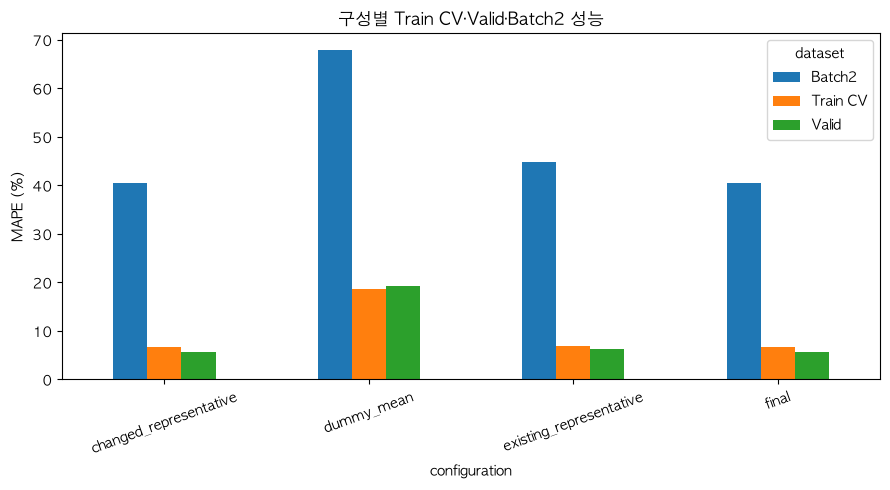

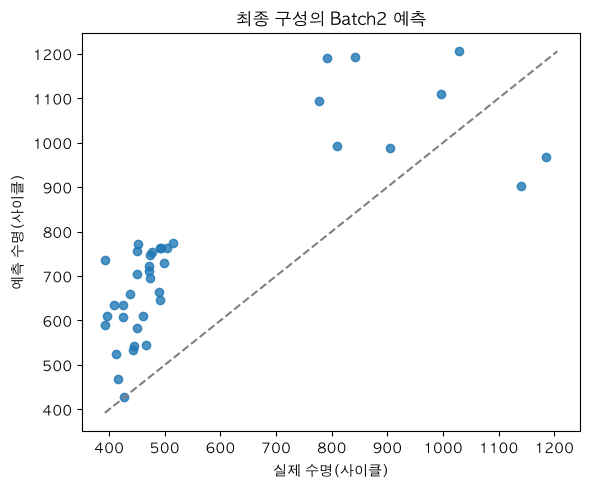

In [11]:
figures = plot_results(result)
for figure in figures:
    display(figure)
    plt.close(figure)

## 12. 실행 결과의 범위

- 이 노트북과 `main.py`는 같은 설정·분할·후보·평가 코드를 사용합니다.
- 노트북은 결과를 표시하기 위해 모델을 다시 학습하지 않습니다.
- Batch3는 데이터 폴더에 있어도 처리하지 않습니다.
- Batch2를 이미 확인한 후속 작업이므로 결과는 탐색 실험입니다.
- 9.1%는 비교 목표이며 동일 분할의 논문 재현 성능이 아닙니다.
- 단계적 선별은 탐색량을 줄이는 방법이며 전체 조합의 최적해를 보장하지 않습니다.
- 원본 데이터, 결과표, 모델과 그래프를 별도 `assets/`에 PNG로 저장하고 화면에도 표시합니다.

## 13. 최종 결론과 ESS 해석

최종 선택은 **Ridge(alpha=1.0), log10 수명, C-capacity + 상대 용량 변화**입니다. 입력은 ΔQ 로그 분산·최솟값, 평균 Qd, 초기 Qd 기울기, 상대 용량 변화입니다.

| 구간 | MAPE(%) | MAE(사이클) | RMSE(사이클) |
|---|---:|---:|---:|
| Train 내부 CV | 6.574 | 55.902 | 72.939 |
| Valid | 5.655 | 54.443 | 69.442 |
| Batch2 | 40.396 | 209.466 | 226.905 |

기존 피처 대표의 Batch2 MAPE 44.701%보다 변경 피처 대표는 약 4.305%p 낮았습니다. 하지만 Batch2의 단수명 28셀은 모두 과대 예측되었습니다. 학습에 없는 수명 구간과 배치별 입력·실험 조건 차이를 함께 확인해야 합니다. 무전류 그룹과 프로토콜 접미사가 같은 집단과 겹치므로 각각의 인과 효과를 분리할 수 없습니다.

과제 참고값 9.1%와의 GAP은 31.296%p입니다. 논문의 특정 실험과 동일한 배치·분할·처리라고 확인된 것은 아니므로 논문 재현 성능으로 표현하지 않습니다.

ESS에서는 셀 선별·추가 검사 우선순위를 검토하는 참고 연구로 해석합니다. 과대 예측은 점검 판단을 늦출 위험이 있습니다. 실제 적용에는 목표 운전 조건의 단수명 데이터와 프로토콜 정보를 확보하고 독립 데이터로 검증해야 합니다.

EDA는 현재 품질 처리 기준으로 재계산했고 후기 기록·무전류 그룹은 설명에만 사용했습니다. main.py 진입점과 노트북의 수치 결과가 일치함을 확인했습니다. 설정을 변경하면 전체 재실행하고 이 결론의 수치를 갱신해야 합니다.
